# Cats & Dogs bootstrap (CIFAR-10)

CIFAR-10 is tiny and still available. We grab cat/dog samples from it,
save a minimal folder structure under `data/cats_dogs/`, show a couple of
images, print label counts, and preload tiny text/image embedding models
for the attention experiments. Run from the repo root (ensure `data/` is
writable).

In [42]:
from __future__ import annotations

from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image
import torchvision
from torchvision import transforms

DATA_ROOT = Path("data/cats_dogs")
CIFAR_ROOT = Path("data/cifar10")
TARGET_PER_CLASS = 500  # matches captioning_test.py (~1000 total)

DATA_ROOT.mkdir(parents=True, exist_ok=True)

transform = transforms.ToTensor()
train_set = torchvision.datasets.CIFAR10(
    root=str(CIFAR_ROOT), train=True, download=True, transform=transform
)
test_set = torchvision.datasets.CIFAR10(
    root=str(CIFAR_ROOT), train=False, download=True, transform=transform
)

cat_label = 3  # "cat"
dog_label = 5  # "dog"
label_names = {cat_label: "cat", dog_label: "dog"}


print("done")


done


In [43]:
def counts_by_label(ds) -> Counter:
    return Counter(label for _, label in ds)

train_counts = counts_by_label(train_set)
test_counts = counts_by_label(test_set)
print("Train cats/dogs:", {k: train_counts[k] for k in label_names})
print("Test cats/dogs:", {k: test_counts[k] for k in label_names})

def first_k(ds, label, k):
    found = []
    for img, lbl in ds:
        if lbl == label:
            found.append(img)
            if len(found) >= k:
                break
    return found

cats_dir = DATA_ROOT / "cats"
dogs_dir = DATA_ROOT / "dogs"
cats_dir.mkdir(parents=True, exist_ok=True)
dogs_dir.mkdir(parents=True, exist_ok=True)

cats = first_k(train_set, cat_label, TARGET_PER_CLASS)
dogs = first_k(train_set, dog_label, TARGET_PER_CLASS)

cat_paths: list[Path] = []
dog_paths: list[Path] = []
for i, img in enumerate(cats):
    path = cats_dir / f"cat_{i}.png"
    if not path.exists():
        transforms.ToPILImage()(img).save(path)
    cat_paths.append(path)
for i, img in enumerate(dogs):
    path = dogs_dir / f"dog_{i}.png"
    if not path.exists():
        transforms.ToPILImage()(img).save(path)
    dog_paths.append(path)

print(f"Saved/kept {len(cat_paths)} cat images")
print(f"Saved/kept {len(dog_paths)} dog images")

# Keep a tiny sample for quick visualization below
sample_paths = cat_paths[:2] + dog_paths[:2]


Train cats/dogs: {3: 5000, 5: 5000}
Test cats/dogs: {3: 1000, 5: 1000}
Saved/kept 500 cat images
Saved/kept 500 dog images


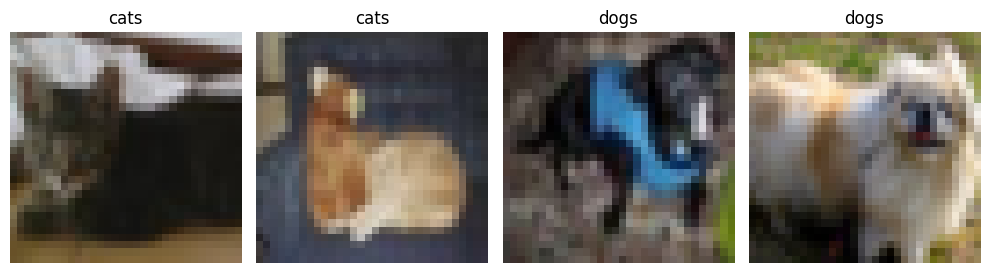

In [44]:
fig, axes = plt.subplots(1, len(sample_paths), figsize=(10, 3))
for ax, path in zip(axes, sample_paths):
    with Image.open(path) as img:
        ax.imshow(img)
    ax.set_title(path.parent.name)
    ax.axis("off")
plt.tight_layout()


In [45]:
# Tiny embedding backbones: MobileNetV3-Small (image) + bert-tiny (text)
import torch
from torchvision import models
from transformers import AutoModel, AutoTokenizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type != "cuda":
    print("[warn] CUDA not available, running on CPU.")
print(f"Using device for embeddings: {device}")

TEXT_MODEL_NAME = "prajjwal1/bert-tiny"
image_weights = models.MobileNet_V3_Small_Weights.DEFAULT
image_model = models.mobilenet_v3_small(weights=image_weights).to(device).eval()
image_preprocess = image_weights.transforms()

tokenizer = AutoTokenizer.from_pretrained(TEXT_MODEL_NAME)
text_model = AutoModel.from_pretrained(TEXT_MODEL_NAME).to(device).eval()

sample_texts = ["a photo of a cat", "a photo of a dog"]
with torch.no_grad():
    text_batch = tokenizer(sample_texts, return_tensors="pt", padding=True, truncation=True).to(device)
    text_embeddings = text_model(**text_batch).last_hidden_state[:, 0]
print("Text CLS embeddings shape:", tuple(text_embeddings.shape))

sample_image_path = cat_paths[0]
with Image.open(sample_image_path).convert("RGB") as img:
    img_tensor = image_preprocess(img).unsqueeze(0).to(device)
    with torch.no_grad():
        image_features = image_model.features(img_tensor).mean(dim=[2, 3])
print("Image feature shape:", tuple(image_features.shape))


Using device for embeddings: cuda


Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Text CLS embeddings shape: (2, 128)
Image feature shape: (1, 576)


[load] Loaded 1000 caption records from data/cats_dogs/captions_from_vlm.json
as you can most likely see, the captions aren't always perfect. But this is just an example and on average they'll be OK.


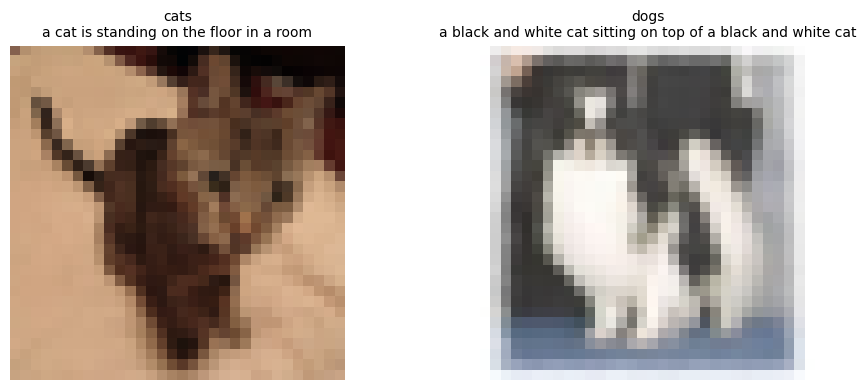

In [46]:
# === View precomputed BLIP captions (from captioning_test.py) ===
import json
from pathlib import Path

image_root = Path("data/cats_dogs")
caption_path = image_root / "captions_from_vlm.json"

if not caption_path.exists():
    raise FileNotFoundError("Run captioning_test.py to produce captions_from_vlm.json before running this cell.")

with open(caption_path) as f:
    caption_records = json.load(f)
print(f"[load] Loaded {len(caption_records)} caption records from {caption_path}")

def class_name(path_str: str):
    return Path(path_str).parent.name

# Pick one cat and one dog to visualize with captions
samples = []
seen = set()
for rec in caption_records:
    cls = class_name(rec["image_path"])
    if cls not in seen:
        samples.append(rec)
        seen.add(cls)
    if len(samples) >= 2:
        break

fig, axes = plt.subplots(1, len(samples), figsize=(10, 4))
if len(samples) == 1:
    axes = [axes]
for ax, rec in zip(axes, samples):
    with Image.open(rec["image_path"]).convert("RGB") as img:
        ax.imshow(img)
    cls = class_name(rec["image_path"])
    caption = rec.get("caption", "")
    ax.set_title(f"{cls}\n{caption}", fontsize=10)
    ax.axis("off")
plt.tight_layout()

print("as you can most likely see, the captions aren't always perfect. But this is just an example and on average they'll be OK.")


In [47]:
# === Load precomputed BLIP embeddings (raw + augmented) ===
import numpy as np
from pathlib import Path

image_embed_raw_path = Path("data/cats_dogs/cats_dogs_blip_image_embeds_raw.npy")
text_embed_raw_path  = Path("data/cats_dogs/cats_dogs_blip_text_embeds_raw.npy")
image_embed_aug_path = Path("data/cats_dogs/cats_dogs_blip_image_embeds_augmented.npy")
text_embed_aug_path  = Path("data/cats_dogs/cats_dogs_blip_text_embeds_augmented.npy")

paths = [image_embed_raw_path, text_embed_raw_path, image_embed_aug_path, text_embed_aug_path]
missing = [p for p in paths if not p.exists()]
if missing:
    raise FileNotFoundError(f"Missing embedding files (run captioning_test.py): {missing}")

img_emb_raw = np.load(image_embed_raw_path)
txt_emb_raw = np.load(text_embed_raw_path)
img_emb_aug = np.load(image_embed_aug_path)
txt_emb_aug = np.load(text_embed_aug_path)

print(f"RAW image embeddings: {img_emb_raw.shape}, dtype={img_emb_raw.dtype}")
print(f"RAW text embeddings:  {txt_emb_raw.shape}, dtype={txt_emb_raw.dtype}")
print(f"AUG image embeddings: {img_emb_aug.shape}, dtype={img_emb_aug.dtype}  (axis1: raw + augs)")
print(f"AUG text embeddings:  {txt_emb_aug.shape}, dtype={txt_emb_aug.dtype}  (axis1: raw + augs)")

# Basic consistency checks
expected = len(caption_records)
if img_emb_raw.shape[0] != expected or txt_emb_raw.shape[0] != expected:
    print(f"[warn] RAW embed count mismatch vs captions ({expected})")
if img_emb_aug.shape[0] != expected or txt_emb_aug.shape[0] != expected:
    print(f"[warn] AUG embed count mismatch vs captions ({expected})")

# Show augmentation types for the first record
first = caption_records[0]
print("Example augmentation types for first sample:")
print("  image:", first.get("image_augmentations", []))
print("  text: ", first.get("text_augmentations", []))


RAW image embeddings: (1000, 512), dtype=float32
RAW text embeddings:  (1000, 512), dtype=float32
AUG image embeddings: (1000, 6, 512), dtype=float32  (axis1: raw + augs)
AUG text embeddings:  (1000, 6, 512), dtype=float32  (axis1: raw + augs)
Example augmentation types for first sample:
  image: ['gaussian_blur', 'random_affine', 'identity', 'color_jitter', 'identity']
  text:  ['identity', 'mask_some_words', 'identity', 'shuffle_middle_words', 'mask_some_words']


In [48]:
# === Instantiate datamodule (all views) and helper ===
import sys
import numpy as np
from pathlib import Path

cats_dogs_dir = Path("shimmer/examples/cats_dogs_attention").resolve()
if str(cats_dogs_dir) not in sys.path:
    sys.path.append(str(cats_dogs_dir))

from dataset import (
    make_datamodule_cats_dogs_blip,
    DEFAULT_IMAGE_LATENTS,
)

image_embed_aug_path = Path(DEFAULT_IMAGE_LATENTS)
views_per_sample = np.load(image_embed_aug_path).shape[1]
print(f"views_per_sample (raw+augs): {views_per_sample}")

def is_augmented(flat_index: int, views_per_sample: int = views_per_sample) -> bool:
    """Return True if a flattened index corresponds to an augmented view (not raw)."""
    if views_per_sample <= 0:
        raise ValueError("views_per_sample must be >= 1")
    return (flat_index % views_per_sample) != 0

# Build datamodule using all views (flattened).
# Note: do not iterate here; some CombinedLoader wrappers return tuples.
dm = make_datamodule_cats_dogs_blip(
    view_mode="all",
    batch_size=256,
    num_workers=0,  # safe for notebook
    pin_memory=False,
)
print("Datamodule instantiated (all views, flattened).")


views_per_sample (raw+augs): 6
[load] Loading array from /home/rbertin/attention/update_shimmer/shimmer/examples/cats_dogs_attention/data/cats_dogs/cats_dogs_blip_image_embeds_augmented.npy ...
[load] Loaded array with shape (1000, 6, 512), dtype=float32
[load] Loading array from /home/rbertin/attention/update_shimmer/shimmer/examples/cats_dogs_attention/data/cats_dogs/cats_dogs_blip_text_embeds_augmented.npy ...
[load] Loaded array with shape (1000, 6, 512), dtype=float32
[cats_dogs] Loaded arrays:
  image_all: N=1000, V=6, D=512
  text_all : N=1000, V=6, D=512
[split] Random split over N=1000: train=800, val=200
[cats_dogs] Split (all):
  train image_latents  : (4800, 512)
  train caption_embeds : (4800, 512)
  val   image_latents  : (1200, 512)
  val   caption_embeds : (1200, 512)
No extra normalization (using extractor’s L2-normalized features).
Datamodule instantiated (all views, flattened).


In [49]:
# Cell 1: GW imports, config, and helper MLP blocks

from pathlib import Path
from typing import Dict

import torch
import torch.nn as nn
from lightning.pytorch import Trainer, seed_everything
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import LearningRateMonitor, ModelCheckpoint

from shimmer import BroadcastLossCoefs
from shimmer.modules.global_workspace import GlobalWorkspaceFusion
from domains import BasicImageDomain, TextDomain

# --- Basic training config (feel free to tweak) ---
SEED       = 42
MAX_STEPS  = 200
VAL_CHECK  = 0.
GRAD_CLIP  = 0.0

WORKSPACE_DIM = 512
N_LAYERS      = 2
HIDDEN_DIM    = 768
DROPOUT       = 0.1

LR           = 5e-4
WEIGHT_DECAY = 1e-5

PRECISION = "bf16-mixed" if torch.cuda.is_bf16_supported() else "16-mixed"

BASE_LOG_DIR  = Path("./logs_cats_dogs_gw")
BASE_CKPT_DIR = Path("./checkpoints_cats_dogs_gw")

RUN_NAME = "cats_dogs_gw_basic"
LOG_DIR  = BASE_LOG_DIR / RUN_NAME
CKPT_DIR = BASE_CKPT_DIR / RUN_NAME


# --- Tiny residual MLP stack for encoders/decoders ---

class ResMLPBlock(nn.Module):
    def __init__(self, dim: int, hidden: int, dropout: float = 0.1):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.fc1  = nn.Linear(dim, hidden)
        self.act  = nn.GELU()
        self.drop = nn.Dropout(dropout)
        self.fc2  = nn.Linear(hidden, dim)

    def forward(self, x):
        h = self.norm(x)
        h = self.fc1(h)
        h = self.act(h)
        h = self.drop(h)
        h = self.fc2(h)
        return x + h


def make_encoder(in_dim: int, workspace_dim: int, n_layers: int, hidden: int, dropout: float) -> nn.Sequential:
    layers = [nn.Linear(in_dim, workspace_dim), nn.GELU()]
    for _ in range(n_layers):
        layers.append(ResMLPBlock(workspace_dim, hidden, dropout))
    return nn.Sequential(*layers)


def make_decoder(out_dim: int, workspace_dim: int, n_layers: int, hidden: int, dropout: float) -> nn.Sequential:
    layers = []
    for _ in range(n_layers):
        layers.append(ResMLPBlock(workspace_dim, hidden, dropout))
    layers.append(nn.Linear(workspace_dim, out_dim))
    return nn.Sequential(*layers)


In [50]:
# Cell 2: Build GlobalWorkspaceFusion model using the cats/dogs datamodule `dm`

from lightning.pytorch.callbacks import Callback

# Collect metrics live (no file reads)
METRIC_KEYS_VAL = ["val/contrastives", "val/translations", "val/demi_cycles", "val/cycles"]
METRIC_KEYS_TRAIN = ["train/contrastives", "train/translations", "train/demi_cycles", "train/cycles"]
train_history = []
val_history = []

class MetricsCollector(Callback):
    def __init__(self, train_keys, val_keys):
        super().__init__()
        self.train_keys = train_keys
        self.val_keys = val_keys

    def _grab(self, trainer, keys):
        rec = {}
        for k in keys:
            val = trainer.callback_metrics.get(k)
            if val is not None:
                rec[k] = float(val.detach().cpu()) if hasattr(val, "detach") else float(val)
        return rec

    def on_train_epoch_end(self, trainer, pl_module):
        rec = self._grab(trainer, self.train_keys)
        if rec:
            train_history.append(rec)

    def on_validation_epoch_end(self, trainer, pl_module):
        rec = self._grab(trainer, self.val_keys)
        if rec:
            val_history.append(rec)


# Repro
seed_everything(SEED, workers=True)

# Grab joint (image + caption) train dataset from the datamodule
# (this follows the structure from dataset_cats_dogs_blip_aug.py)
train_pair = dm.train_datasets[frozenset(["image_latents", "caption_embeddings"])]

img_dim = int(train_pair.domain_data["image_latents"].shape[1])
txt_dim = int(train_pair.domain_data["caption_embeddings"].shape[1])

print(f"image_latents dim = {img_dim}")
print(f"caption_embeddings dim = {txt_dim}")

# Domain modules (2-mod setup: image_latents ↔ caption_embeddings)
domain_mods: Dict[str, nn.Module] = {
    "image_latents":      BasicImageDomain(latent_dim=img_dim),
    "caption_embeddings": TextDomain(latent_dim=txt_dim),
}

# Encoders / decoders into the workspace
gw_encoders = {
    "image_latents":      make_encoder(img_dim, WORKSPACE_DIM, N_LAYERS, HIDDEN_DIM, DROPOUT),
    "caption_embeddings": make_encoder(txt_dim, WORKSPACE_DIM, N_LAYERS, HIDDEN_DIM, DROPOUT),
}
gw_decoders = {
    "image_latents":      make_decoder(img_dim, WORKSPACE_DIM, N_LAYERS, HIDDEN_DIM, DROPOUT),
    "caption_embeddings": make_decoder(txt_dim, WORKSPACE_DIM, N_LAYERS, HIDDEN_DIM, DROPOUT),
}

# Broadcast loss mix (2-mod friendly)
loss_coefs = BroadcastLossCoefs(
    translations=1.0,   # X→Y, Y→X
    demi_cycles=0.5,    # X→Y→X, Y→X→Y
    cycles=0.5,         # full cycles (if defined)
    contrastives=0.1,  # CL-like
)

# Simple cosine LR scheduler with warmup (same style as your script)
import math

def sched_cosine_warmup(optimizer, total_steps: int, warmup_steps: int = 1_000):
    def lr_lambda(step: int):
        if step < warmup_steps:
            return float(step) / max(1, warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1.0 + math.cos(math.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)


scheduler_fn = lambda optim: sched_cosine_warmup(
    optim,
    total_steps=MAX_STEPS,
    warmup_steps=min(1_000, MAX_STEPS // 5),
)

# Instantiate GW LightningModule
model = GlobalWorkspaceFusion(
    domain_mods=domain_mods,
    gw_encoders=gw_encoders,
    gw_decoders=gw_decoders,
    workspace_dim=WORKSPACE_DIM,
    loss_coefs=loss_coefs,
    optim_lr=LR,
    optim_weight_decay=WEIGHT_DECAY,
    scheduler=scheduler_fn,
    scheduler_args=None,
)

# Logging / checkpoints (local only, NO W&B)
LOG_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

csv_logger = CSVLogger(
    save_dir=str(LOG_DIR),
    name=RUN_NAME,
    flush_logs_every_n_steps=50,
)

metric_cb = MetricsCollector(METRIC_KEYS_TRAIN, METRIC_KEYS_VAL)
lr_cb = LearningRateMonitor(logging_interval="step")
ckpt_cb = ModelCheckpoint(
    dirpath=str(CKPT_DIR),
    filename=RUN_NAME + "-{epoch:02d}-{step:06d}",
    save_last=True,
    save_top_k=3,
    monitor="val/loss",
    mode="min",
)

trainer = Trainer(
    logger=[csv_logger],
    callbacks=[lr_cb, ckpt_cb, metric_cb],
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    max_steps=MAX_STEPS,
    log_every_n_steps=50,
    val_check_interval=VAL_CHECK,
    num_sanity_val_steps=0,
    detect_anomaly=False,
    gradient_clip_val=GRAD_CLIP,
    precision=PRECISION,
    enable_checkpointing=True,
)

print("✅ GlobalWorkspaceFusion model and Trainer are ready.")
print(f"Logs will go to : {LOG_DIR.resolve()}")
print(f"Ckpts will go to: {CKPT_DIR.resolve()}")


Seed set to 42
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


image_latents dim = 512
caption_embeddings dim = 512
✅ GlobalWorkspaceFusion model and Trainer are ready.
Logs will go to : /home/rbertin/attention/update_shimmer/shimmer/examples/cats_dogs_attention/logs_cats_dogs_gw/cats_dogs_gw_basic
Ckpts will go to: /home/rbertin/attention/update_shimmer/shimmer/examples/cats_dogs_attention/checkpoints_cats_dogs_gw/cats_dogs_gw_basic


In [51]:
# Cell 3: Run GW training on the cats/dogs datamodule `dm`

print("\n[Cats & Dogs] Training GlobalWorkspaceFusion (image_latents ↔ caption_embeddings)")
print(f"Run name: {RUN_NAME}")

trainer.fit(model=model, datamodule=dm)

print("\n✅ Training finished.")
print(f"Logs dir : {LOG_DIR.resolve()}")
print(f"Ckpt dir : {CKPT_DIR.resolve()}")

if torch.cuda.is_available():
    torch.cuda.empty_cache()


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [1]

  | Name          | Type            | Params | Mode 
----------------------------------------------------------
0 | gw_mod        | GWModule        | 7.4 M  | train
1 | selection_mod | RandomSelection | 0      | train
2 | loss_mod      | GWLosses        | 7.4 M  | train
----------------------------------------------------------
7.4 M     Trainable params
0         Non-trainable params
7.4 M     Total params
29.442    Total estimated model params size (MB)
65        Modules in train mode
2         Modules in eval mode



[Cats & Dogs] Training GlobalWorkspaceFusion (image_latents ↔ caption_embeddings)
Run name: cats_dogs_gw_basic
Epoch 10:  53%|█████▎    | 10/19 [00:05<00:04,  1.90it/s, v_num=9]

`Trainer.fit` stopped: `max_steps=200` reached.


Epoch 10:  53%|█████▎    | 10/19 [00:05<00:04,  1.90it/s, v_num=9]

✅ Training finished.
Logs dir : /home/rbertin/attention/update_shimmer/shimmer/examples/cats_dogs_attention/logs_cats_dogs_gw/cats_dogs_gw_basic
Ckpt dir : /home/rbertin/attention/update_shimmer/shimmer/examples/cats_dogs_attention/checkpoints_cats_dogs_gw/cats_dogs_gw_basic


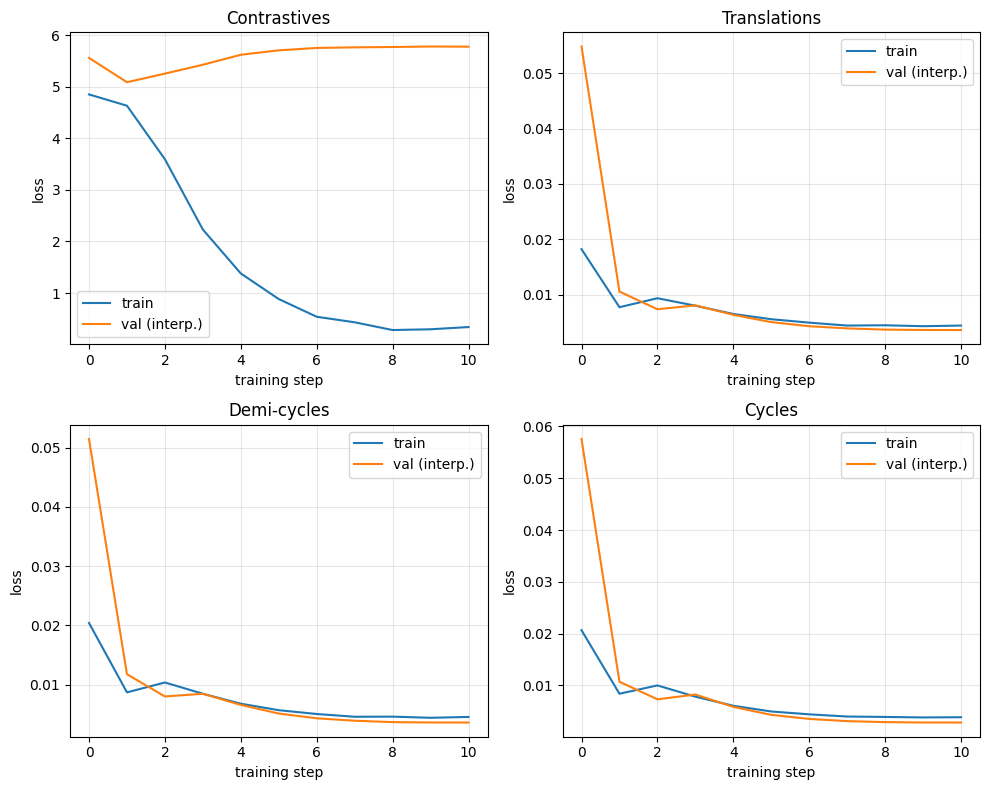

In [52]:
# Cell 4 (rewritten): Plot train/val losses with interpolated val curves
import numpy as np
import matplotlib.pyplot as plt

if not val_history or not train_history:
    print("No metrics captured yet. Run the training cell first.")
else:
    n_train = len(train_history)
    n_val = len(val_history)

    if n_val < 2:
        print("Not enough val points to interpolate (need at least 2).")
    else:
        # "step" indices for train (0..n_train-1)
        steps = np.arange(n_train)

        # Assume val points span the same training range; spread them evenly
        val_positions = np.linspace(0, n_train - 1, num=n_val)

        pairs = {
            "Contrastives": ("train/contrastives", "val/contrastives"),
            "Translations": ("train/translations", "val/translations"),
            "Demi-cycles": ("train/demi_cycles", "val/demi_cycles"),
            "Cycles": ("train/cycles", "val/cycles"),
        }

        fig, axes = plt.subplots(2, 2, figsize=(10, 8))
        axes = axes.flatten()

        for ax, (title, (ktr, kval)) in zip(axes, pairs.items()):
            # Extract raw train values (length = n_train)
            train_vals = np.array(
                [rec.get(ktr, np.nan) for rec in train_history],
                dtype=float,
            )

            # Extract sparse val values (length = n_val)
            val_raw = np.array(
                [rec.get(kval, np.nan) for rec in val_history],
                dtype=float,
            )

            # Simple nan handling: if all vals are nan, skip plot
            if np.all(np.isnan(train_vals)) and np.all(np.isnan(val_raw)):
                ax.set_title(title + " (no data)")
                ax.grid(True, alpha=0.3)
                continue

            # Interpolate val to full train length
            # (np.interp ignores nans poorly, so we mask them out first)
            valid_mask = ~np.isnan(val_raw)
            if valid_mask.sum() >= 2:
                val_interp = np.interp(
                    steps,
                    val_positions[valid_mask],
                    val_raw[valid_mask],
                )
            elif valid_mask.sum() == 1:
                # Only one valid point → flat line
                val_interp = np.full_like(train_vals, val_raw[valid_mask][0])
            else:
                val_interp = np.full_like(train_vals, np.nan)

            ax.plot(steps, train_vals, label="train", color="tab:blue")
            ax.plot(steps, val_interp, label="val (interp.)", color="tab:orange")
            ax.set_title(title)
            ax.set_xlabel("training step")
            ax.set_ylabel("loss")
            ax.grid(True, alpha=0.3)
            ax.legend()

        plt.tight_layout()

